In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

DATASET1 = '../data/train'
DATASET2 = '../data/val'
DATASET3 = '../data/test'

print("Imports done!")
print("Dataset 1:", os.path.exists(DATASET1))
print("Dataset 2:", os.path.exists(DATASET2))
print("Dataset 3:", os.path.exists(DATASET3))

Imports done!
Dataset 1: True
Dataset 2: True
Dataset 3: True


In [17]:
def explore_dataset(path, name):
    print(f"\n--- {name} ---")
    total = 0
    for label in ['NORMAL', 'PNEUMONIA']:
        folder = os.path.join(path, label)
        files = [f for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]
        print(f"  {label}: {len(files)} images")
        total += len(files)
    print(f"  TOTAL: {total} images")

explore_dataset(DATASET1, 'Dataset 1 Train')
explore_dataset(DATASET2, 'Dataset 2 Val')
explore_dataset(DATASET3, 'Dataset 3 Test')


--- Dataset 1 Train ---
  NORMAL: 1341 images
  PNEUMONIA: 3875 images
  TOTAL: 5216 images

--- Dataset 2 Val ---
  NORMAL: 8 images
  PNEUMONIA: 8 images
  TOTAL: 16 images

--- Dataset 3 Test ---
  NORMAL: 234 images
  PNEUMONIA: 390 images
  TOTAL: 624 images


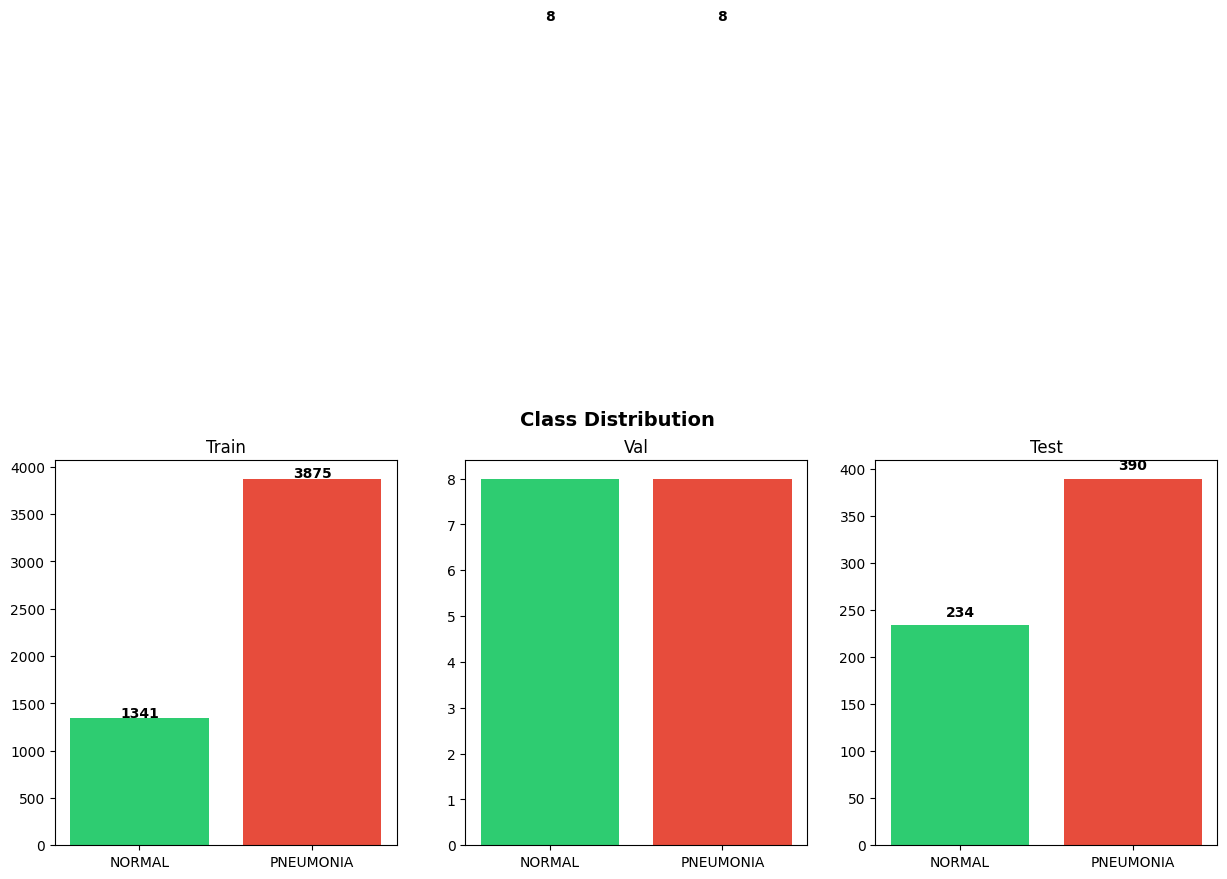

In [18]:
datasets = {
    'Train': DATASET1,
    'Val':   DATASET2,
    'Test':  DATASET3
}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, path) in zip(axes, datasets.items()):
    counts = []
    for label in ['NORMAL', 'PNEUMONIA']:
        folder = os.path.join(path, label)
        files = [f for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]
        counts.append(len(files))
    ax.bar(['NORMAL', 'PNEUMONIA'], counts, color=['#2ecc71','#e74c3c'])
    ax.set_title(name)
    for i, v in enumerate(counts):
        ax.text(i, v+10, str(v), ha='center', fontweight='bold')
plt.suptitle('Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/class_distribution.png', dpi=150)
plt.show()

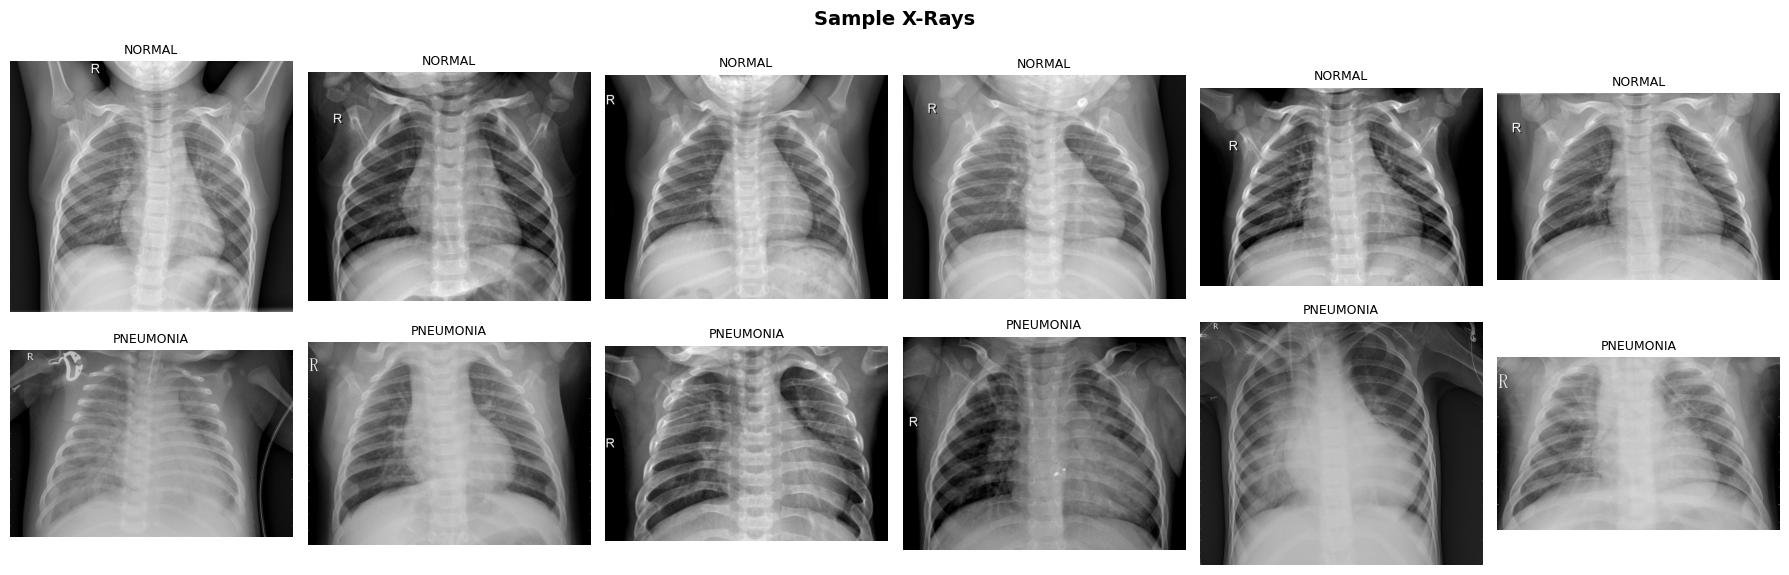

In [19]:
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for col, label in enumerate(['NORMAL', 'PNEUMONIA']):
    folder = os.path.join(DATASET1, label)
    files = [f for f in os.listdir(folder)
             if f.lower().endswith(('.jpg','.jpeg','.png'))][:6]
    for row, fname in enumerate(files):
        img = Image.open(os.path.join(folder, fname)).convert('L')
        axes[col][row].imshow(img, cmap='gray')
        axes[col][row].set_title(label, fontsize=9)
        axes[col][row].axis('off')
plt.suptitle('Sample X-Rays', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/sample_xrays.png', dpi=150)
plt.show()

In [20]:
def load_dataset(path, size=(128, 128), rotate=False):
    X, y = [], []
    for label, val in [('NORMAL', 0), ('PNEUMONIA', 1)]:
        folder = os.path.join(path, label)
        files = [f for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]
        for fname in files:
            try:
                img = Image.open(os.path.join(folder, fname)).convert('L')
                img = img.resize(size)
                X.append(np.array(img).flatten() / 255.0)
                y.append(val)
                if rotate:
                    img_rotated = img.rotate(15)
                    X.append(np.array(img_rotated).flatten() / 255.0)
                    y.append(val)
            except:
                print(f"Skipped: {fname}")
    return np.array(X), np.array(y)

print("load_dataset function ready!")

load_dataset function ready!


In [21]:
print("Loading Dataset 1 (Train)...")
X_train_raw, y_train = load_dataset(DATASET1, rotate=False)
print(f"Done! Shape: {X_train_raw.shape}")

print("\nLoading Dataset 2 (Val)...")
X_val_raw, y_val = load_dataset(DATASET2)
print(f"Done! Shape: {X_val_raw.shape}")

print("\nLoading Dataset 3 (Test)...")
X_test_raw, y_test = load_dataset(DATASET3)
print(f"Done! Shape: {X_test_raw.shape}")

Loading Dataset 1 (Train)...
Done! Shape: (5216, 16384)

Loading Dataset 2 (Val)...
Done! Shape: (16, 16384)

Loading Dataset 3 (Test)...
Done! Shape: (624, 16384)


In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled   = scaler.transform(X_val_raw)
X_test_scaled  = scaler.transform(X_test_raw)
print("Scaling done!")

pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)
print("PCA done!")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}")

Scaling done!
PCA done!
Variance explained: 87.88%


In [23]:
print("=" * 50)
print("ALL DONE — READY FOR MODELS")
print("=" * 50)
print(f"X_train_pca : {X_train_pca.shape}")
print(f"X_val_pca   : {X_val_pca.shape}")
print(f"X_test_pca  : {X_test_pca.shape}")
print(f"y_train     : Normal={( y_train==0).sum()} Pneumonia={(y_train==1).sum()}")

ALL DONE — READY FOR MODELS
X_train_pca : (5216, 100)
X_val_pca   : (16, 100)
X_test_pca  : (624, 100)
y_train     : Normal=1341 Pneumonia=3875


In [24]:
import joblib

# Cache directory
CACHE_DIR = '../data/preprocessed'
os.makedirs(CACHE_DIR, exist_ok=True)

# Save raw arrays
np.save(f'{CACHE_DIR}/X_train.npy', X_train_raw)
np.save(f'{CACHE_DIR}/y_train.npy', y_train)
np.save(f'{CACHE_DIR}/X_val.npy',   X_val_raw)
np.save(f'{CACHE_DIR}/y_val.npy',   y_val)
np.save(f'{CACHE_DIR}/X_test.npy',  X_test_raw)
np.save(f'{CACHE_DIR}/y_test.npy',  y_test)

# Save scaler and PCA
joblib.dump(scaler, f'{CACHE_DIR}/scaler.joblib')
joblib.dump(pca,    f'{CACHE_DIR}/pca.joblib')

print("All saved to cache!")
print(f"Location: {CACHE_DIR}")

All saved to cache!
Location: ../data/preprocessed


In [25]:
from sklearn.model_selection import train_test_split

# Split 1 — Simple Train/Test
X_split1_train, X_split1_test, y_split1_train, y_split1_test = train_test_split(
    X_train_pca, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Split 1 — Simple Train/Test Done!")
print(f"  Train : {X_split1_train.shape}")
print(f"  Test  : {X_split1_test.shape}")

Split 1 — Simple Train/Test Done!
  Train : (4172, 100)
  Test  : (1044, 100)


In [26]:
# Split 2 — Train/Val/Test
# Already done by our 3 datasets!
X_split2_train = X_train_pca
X_split2_val   = X_val_pca
X_split2_test  = X_test_pca
y_split2_train = y_train
y_split2_val   = y_val
y_split2_test  = y_test

print("Split 2 — Train/Val/Test Done!")
print(f"  Train : {X_split2_train.shape}")
print(f"  Val   : {X_split2_val.shape}")
print(f"  Test  : {X_split2_test.shape}")

Split 2 — Train/Val/Test Done!
  Train : (5216, 100)
  Val   : (16, 100)
  Test  : (624, 100)


In [27]:
from sklearn.model_selection import StratifiedKFold

# Split 3 — K-Fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Split 3 — K-Fold CV Ready!")
print(f"  Folds          : 5")
print(f"  Total images   : {X_train_pca.shape[0]}")
print(f"  Each fold train: ~{int(X_train_pca.shape[0]*0.8)} images")
print(f"  Each fold test : ~{int(X_train_pca.shape[0]*0.2)} images")

Split 3 — K-Fold CV Ready!
  Folds          : 5
  Total images   : 5216
  Each fold train: ~4172 images
  Each fold test : ~1043 images


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score,
                              confusion_matrix, RocCurveDisplay,
                              ConfusionMatrixDisplay)
from sklearn.model_selection import cross_validate
import matplotlib.pyplot as plt

print("Libraries imported!")

Libraries imported!


In [29]:
# Logistic Regression — Split 1 (Simple Train/Test)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_split1_train, y_split1_train)

y_pred = lr_model.predict(X_split1_test)
y_prob = lr_model.predict_proba(X_split1_test)[:,1]

print("LR — Split 1 (Simple Train/Test)")
print(f"  Accuracy  : {accuracy_score(y_split1_test, y_pred):.4f}")
print(f"  Precision : {precision_score(y_split1_test, y_pred):.4f}")
print(f"  Recall    : {recall_score(y_split1_test, y_pred):.4f}")
print(f"  F1        : {f1_score(y_split1_test, y_pred):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_split1_test, y_prob):.4f}")

LR — Split 1 (Simple Train/Test)
  Accuracy  : 0.9598
  Precision : 0.9779
  Recall    : 0.9678
  F1        : 0.9728
  ROC-AUC   : 0.9891


In [30]:
# Logistic Regression — Split 2 (Train/Val/Test)
lr_model2 = LogisticRegression(max_iter=1000, random_state=42)
lr_model2.fit(X_split2_train, y_split2_train)

y_pred2 = lr_model2.predict(X_split2_test)
y_prob2 = lr_model2.predict_proba(X_split2_test)[:,1]

print("LR — Split 2 (Train/Val/Test)")
print(f"  Accuracy  : {accuracy_score(y_split2_test, y_pred2):.4f}")
print(f"  Precision : {precision_score(y_split2_test, y_pred2):.4f}")
print(f"  Recall    : {recall_score(y_split2_test, y_pred2):.4f}")
print(f"  F1        : {f1_score(y_split2_test, y_pred2):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_split2_test, y_prob2):.4f}")

LR — Split 2 (Train/Val/Test)
  Accuracy  : 0.7484
  Precision : 0.7161
  Recall    : 0.9897
  F1        : 0.8310
  ROC-AUC   : 0.8973


In [31]:
# Logistic Regression — Split 3 (K-Fold CV)
lr_model3 = LogisticRegression(max_iter=1000, random_state=42)

cv_results = cross_validate(
    lr_model3, X_train_pca, y_train,
    cv=skf,
    scoring=['accuracy', 'f1', 'roc_auc'],
    return_train_score=True
)

print("LR — Split 3 (K-Fold CV)")
print(f"  Accuracy  : {cv_results['test_accuracy'].mean():.4f}")
print(f"  F1        : {cv_results['test_f1'].mean():.4f}")
print(f"  ROC-AUC   : {cv_results['test_roc_auc'].mean():.4f}")

LR — Split 3 (K-Fold CV)
  Accuracy  : 0.9559
  F1        : 0.9704
  ROC-AUC   : 0.9871


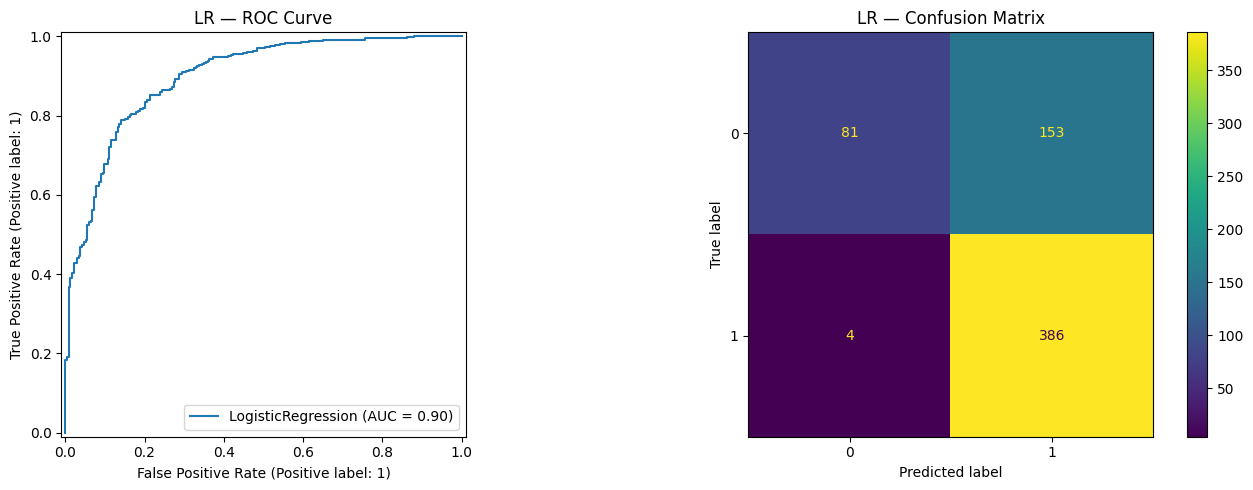

LR plots saved!


In [32]:
# ROC Curve + Confusion Matrix for LR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_estimator(
    lr_model2, X_split2_test, y_split2_test, ax=axes[0])
axes[0].set_title('LR — ROC Curve')

ConfusionMatrixDisplay.from_estimator(
    lr_model2, X_split2_test, y_split2_test, ax=axes[1])
axes[1].set_title('LR — Confusion Matrix')

plt.tight_layout()
plt.savefig('../outputs/figures/LR_evaluation.png', dpi=150)
plt.show()
print("LR plots saved!")

In [33]:
from sklearn.ensemble import RandomForestClassifier

print("Random Forest imported!")

Random Forest imported!


In [34]:
# Random Forest — Split 1 (Simple Train/Test)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_split1_train, y_split1_train)

y_pred_rf = rf_model.predict(X_split1_test)
y_prob_rf = rf_model.predict_proba(X_split1_test)[:,1]

print("RF — Split 1 (Simple Train/Test)")
print(f"  Accuracy  : {accuracy_score(y_split1_test, y_pred_rf):.4f}")
print(f"  Precision : {precision_score(y_split1_test, y_pred_rf):.4f}")
print(f"  Recall    : {recall_score(y_split1_test, y_pred_rf):.4f}")
print(f"  F1        : {f1_score(y_split1_test, y_pred_rf):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_split1_test, y_prob_rf):.4f}")

RF — Split 1 (Simple Train/Test)
  Accuracy  : 0.9416
  Precision : 0.9376
  Recall    : 0.9871
  F1        : 0.9617
  ROC-AUC   : 0.9858


In [35]:
# Random Forest — Split 2 (Train/Val/Test)
rf_model2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model2.fit(X_split2_train, y_split2_train)

y_pred_rf2 = rf_model2.predict(X_split2_test)
y_prob_rf2 = rf_model2.predict_proba(X_split2_test)[:,1]

print("RF — Split 2 (Train/Val/Test)")
print(f"  Accuracy  : {accuracy_score(y_split2_test, y_pred_rf2):.4f}")
print(f"  Precision : {precision_score(y_split2_test, y_pred_rf2):.4f}")
print(f"  Recall    : {recall_score(y_split2_test, y_pred_rf2):.4f}")
print(f"  F1        : {f1_score(y_split2_test, y_pred_rf2):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_split2_test, y_prob_rf2):.4f}")

RF — Split 2 (Train/Val/Test)
  Accuracy  : 0.7436
  Precision : 0.7114
  Recall    : 0.9923
  F1        : 0.8287
  ROC-AUC   : 0.9160


In [36]:
# Random Forest — Split 3 (K-Fold CV)
rf_model3 = RandomForestClassifier(n_estimators=100, random_state=42)

cv_results_rf = cross_validate(
    rf_model3, X_train_pca, y_train,
    cv=skf,
    scoring=['accuracy', 'f1', 'roc_auc'],
    return_train_score=True
)

print("RF — Split 3 (K-Fold CV)")
print(f"  Accuracy  : {cv_results_rf['test_accuracy'].mean():.4f}")
print(f"  F1        : {cv_results_rf['test_f1'].mean():.4f}")
print(f"  ROC-AUC   : {cv_results_rf['test_roc_auc'].mean():.4f}")

RF — Split 3 (K-Fold CV)
  Accuracy  : 0.9329
  F1        : 0.9562
  ROC-AUC   : 0.9833


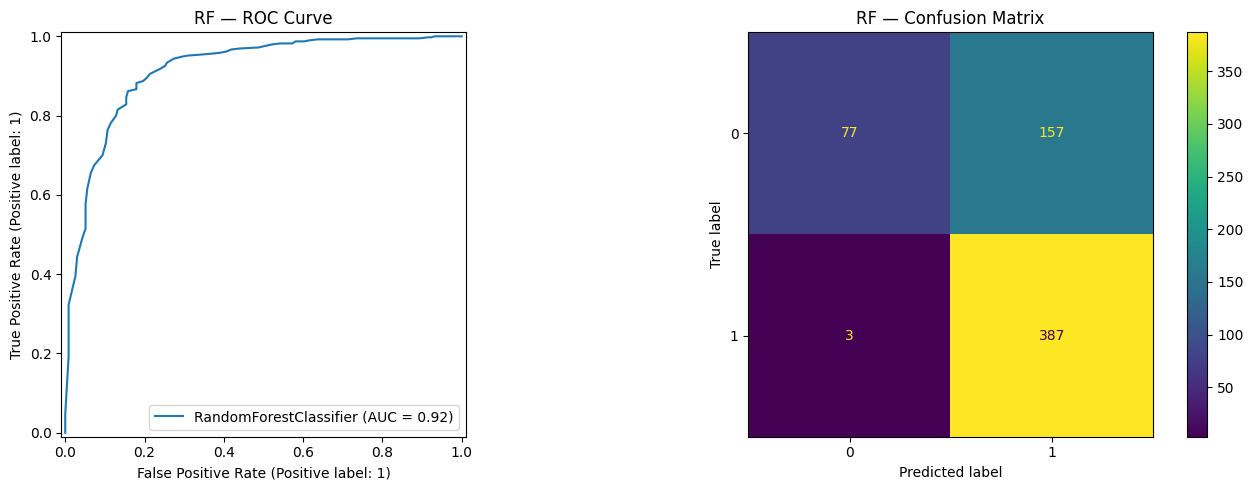

RF plots saved!


In [37]:
# ROC Curve + Confusion Matrix for RF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_estimator(
    rf_model2, X_split2_test, y_split2_test, ax=axes[0])
axes[0].set_title('RF — ROC Curve')

ConfusionMatrixDisplay.from_estimator(
    rf_model2, X_split2_test, y_split2_test, ax=axes[1])
axes[1].set_title('RF — Confusion Matrix')

plt.tight_layout()
plt.savefig('../outputs/figures/RF_evaluation.png', dpi=150)
plt.show()
print("RF plots saved!")

In [38]:
from sklearn.neural_network import MLPClassifier

print("MLP imported!")

MLP imported!


In [39]:
# MLP — Split 1 (Simple Train/Test)
mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    max_iter=300,
    random_state=42
)
mlp_model.fit(X_split1_train, y_split1_train)

y_pred_mlp = mlp_model.predict(X_split1_test)
y_prob_mlp = mlp_model.predict_proba(X_split1_test)[:,1]

print("MLP — Split 1 (Simple Train/Test)")
print(f"  Accuracy  : {accuracy_score(y_split1_test, y_pred_mlp):.4f}")
print(f"  Precision : {precision_score(y_split1_test, y_pred_mlp):.4f}")
print(f"  Recall    : {recall_score(y_split1_test, y_pred_mlp):.4f}")
print(f"  F1        : {f1_score(y_split1_test, y_pred_mlp):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_split1_test, y_prob_mlp):.4f}")

MLP — Split 1 (Simple Train/Test)
  Accuracy  : 0.9617
  Precision : 0.9779
  Recall    : 0.9704
  F1        : 0.9741
  ROC-AUC   : 0.9937


In [40]:
# MLP — Split 2 (Train/Val/Test)
mlp_model2 = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    max_iter=300,
    random_state=42
)
mlp_model2.fit(X_split2_train, y_split2_train)

y_pred_mlp2 = mlp_model2.predict(X_split2_test)
y_prob_mlp2 = mlp_model2.predict_proba(X_split2_test)[:,1]

print("MLP — Split 2 (Train/Val/Test)")
print(f"  Accuracy  : {accuracy_score(y_split2_test, y_pred_mlp2):.4f}")
print(f"  Precision : {precision_score(y_split2_test, y_pred_mlp2):.4f}")
print(f"  Recall    : {recall_score(y_split2_test, y_pred_mlp2):.4f}")
print(f"  F1        : {f1_score(y_split2_test, y_pred_mlp2):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_split2_test, y_prob_mlp2):.4f}")

MLP — Split 2 (Train/Val/Test)
  Accuracy  : 0.7837
  Precision : 0.7466
  Recall    : 0.9897
  F1        : 0.8512
  ROC-AUC   : 0.9032


In [41]:
# MLP — Split 3 (K-Fold CV)
mlp_model3 = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    max_iter=300,
    random_state=42
)

cv_results_mlp = cross_validate(
    mlp_model3, X_train_pca, y_train,
    cv=skf,
    scoring=['accuracy', 'f1', 'roc_auc'],
    return_train_score=True
)

print("MLP — Split 3 (K-Fold CV)")
print(f"  Accuracy  : {cv_results_mlp['test_accuracy'].mean():.4f}")
print(f"  F1        : {cv_results_mlp['test_f1'].mean():.4f}")
print(f"  ROC-AUC   : {cv_results_mlp['test_roc_auc'].mean():.4f}")

MLP — Split 3 (K-Fold CV)
  Accuracy  : 0.9680
  F1        : 0.9785
  ROC-AUC   : 0.9928


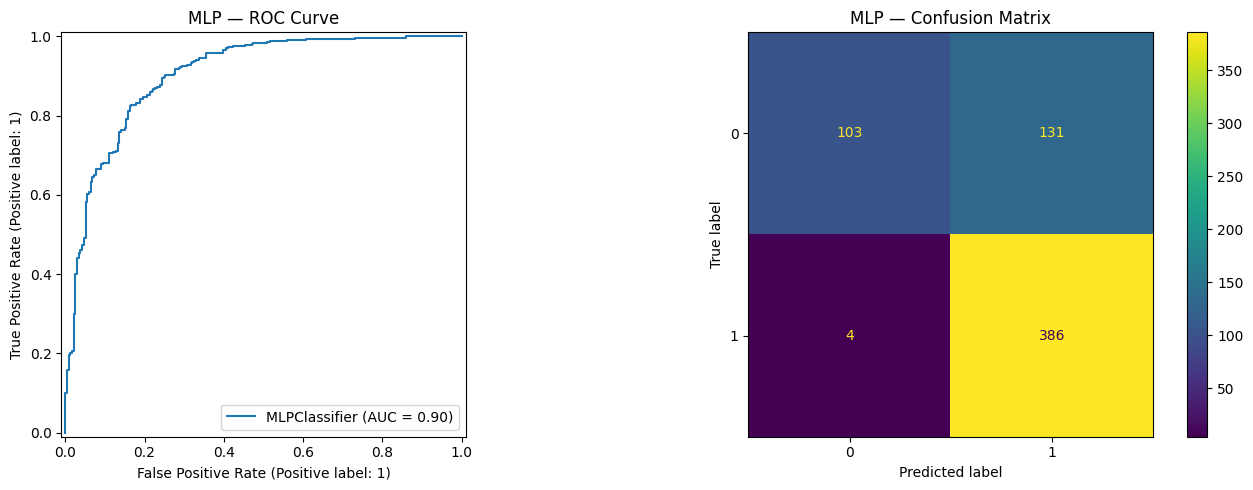

MLP plots saved!


In [42]:
# ROC Curve + Confusion Matrix for MLP
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_estimator(
    mlp_model2, X_split2_test, y_split2_test, ax=axes[0])
axes[0].set_title('MLP — ROC Curve')

ConfusionMatrixDisplay.from_estimator(
    mlp_model2, X_split2_test, y_split2_test, ax=axes[1])
axes[1].set_title('MLP — Confusion Matrix')

plt.tight_layout()
plt.savefig('../outputs/figures/MLP_evaluation.png', dpi=150)
plt.show()
print("MLP plots saved!")

In [43]:
import joblib
from sklearn.pipeline import Pipeline

# Save best model (MLP)
best_pipeline = Pipeline([
    ('scaler', scaler),
    ('pca', pca),
    ('classifier', mlp_model2)
])

joblib.dump(best_pipeline, '../models/best_pipeline.joblib')
print("Best model saved!")
print("Model: MLP Neural Network")
print("Location: models/best_pipeline.joblib")

Best model saved!
Model: MLP Neural Network
Location: models/best_pipeline.joblib


In [44]:
# Test best model on a real image from test set
import joblib
import numpy as np
from PIL import Image
import os

# Load saved pipeline
pipeline = joblib.load('../models/best_pipeline.joblib')
print("Model loaded!")

# Pick one NORMAL image from test set
normal_folder = '../data/test/NORMAL'
normal_files = os.listdir(normal_folder)
test_image_path = os.path.join(normal_folder, normal_files[0])

# Preprocess it
img = Image.open(test_image_path).convert('L')
img = img.resize((128, 128))
X_new = np.array(img).flatten() / 255.0
X_new = X_new.reshape(1, -1)

# Predict
result = pipeline.predict(X_new)[0]
probability = pipeline.predict_proba(X_new)[0]

print(f"\nImage    : {normal_files[0]}")
print(f"Actual   : NORMAL")
print(f"Predicted: {'PNEUMONIA' if result == 1 else 'NORMAL'}")
print(f"Confidence Normal    : {probability[0]:.2%}")
print(f"Confidence Pneumonia : {probability[1]:.2%}")
print(f"\nCorrect  : {result == 0}")

Model loaded!

Image    : IM-0001-0001.jpeg
Actual   : NORMAL
Predicted: NORMAL
Confidence Normal    : 98.82%
Confidence Pneumonia : 1.18%

Correct  : True


In [45]:
# Pick one PNEUMONIA image from test set
pneumonia_folder = '../data/test/PNEUMONIA'
pneumonia_files = os.listdir(pneumonia_folder)
test_image_path2 = os.path.join(pneumonia_folder, pneumonia_files[0])

# Preprocess it
img2 = Image.open(test_image_path2).convert('L')
img2 = img2.resize((128, 128))
X_new2 = np.array(img2).flatten() / 255.0
X_new2 = X_new2.reshape(1, -1)

# Predict
result2 = pipeline.predict(X_new2)[0]
probability2 = pipeline.predict_proba(X_new2)[0]

print(f"Image    : {pneumonia_files[0]}")
print(f"Actual   : PNEUMONIA")
print(f"Predicted: {'PNEUMONIA' if result2 == 1 else 'NORMAL'}")
print(f"Confidence Normal    : {probability2[0]:.2%}")
print(f"Confidence Pneumonia : {probability2[1]:.2%}")
print(f"\nCorrect  : {result2 == 1}")

Image    : person100_bacteria_475.jpeg
Actual   : PNEUMONIA
Predicted: PNEUMONIA
Confidence Normal    : 0.00%
Confidence Pneumonia : 100.00%

Correct  : True


In [46]:
import random

# Test on 5 NORMAL + 5 PNEUMONIA images
correct = 0
total = 0
results = []

for label, folder, true_val in [
    ('NORMAL',    '../data/test/NORMAL',    0),
    ('PNEUMONIA', '../data/test/PNEUMONIA', 1)
]:
    files = os.listdir(folder)
    samples = random.sample(files, 5)
    
    for fname in samples:
        try:
            img = Image.open(os.path.join(folder, fname)).convert('L')
            img = img.resize((128, 128))
            X = np.array(img).flatten() / 255.0
            X = X.reshape(1, -1)
            
            pred = pipeline.predict(X)[0]
            prob = pipeline.predict_proba(X)[0]
            
            is_correct = pred == true_val
            correct += is_correct
            total += 1
            
            results.append({
                'file': fname,
                'actual': label,
                'predicted': 'PNEUMONIA' if pred == 1 else 'NORMAL',
                'correct': '✅' if is_correct else '❌',
                'confidence': f"{max(prob):.2%}"
            })
        except:
            pass

# Print results table
print(f"{'File':<40} {'Actual':<12} {'Predicted':<12} {'Correct':<8} {'Confidence'}")
print("-" * 90)
for r in results:
    print(f"{r['file']:<40} {r['actual']:<12} {r['predicted']:<12} {r['correct']:<8} {r['confidence']}")

print(f"\nTotal Correct : {correct}/{total}")
print(f"Accuracy      : {correct/total:.2%}")

File                                     Actual       Predicted    Correct  Confidence
------------------------------------------------------------------------------------------
NORMAL2-IM-0023-0001.jpeg                NORMAL       PNEUMONIA    ❌        98.76%
NORMAL2-IM-0302-0001.jpeg                NORMAL       PNEUMONIA    ❌        100.00%
IM-0031-0001.jpeg                        NORMAL       NORMAL       ✅        99.86%
NORMAL2-IM-0249-0001.jpeg                NORMAL       PNEUMONIA    ❌        96.17%
IM-0033-0001-0001.jpeg                   NORMAL       PNEUMONIA    ❌        61.43%
person91_bacteria_446.jpeg               PNEUMONIA    PNEUMONIA    ✅        100.00%
person70_virus_130.jpeg                  PNEUMONIA    PNEUMONIA    ✅        100.00%
person1645_virus_2845.jpeg               PNEUMONIA    PNEUMONIA    ✅        99.88%
person26_virus_60.jpeg                   PNEUMONIA    PNEUMONIA    ✅        100.00%
person1662_virus_2875.jpeg               PNEUMONIA    PNEUMONIA    ✅   

In [47]:
# Retrain MLP with balanced class weights
mlp_balanced = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    max_iter=300,
    random_state=42
)

# We handle balance manually using sample weights
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight('balanced', y_split2_train)

mlp_balanced.fit(X_split2_train, y_split2_train,
                  sample_weight=sample_weights)

# Test on same 10 images
correct = 0
total = 0
results = []

for label, folder, true_val in [
    ('NORMAL',    '../data/test/NORMAL',    0),
    ('PNEUMONIA', '../data/test/PNEUMONIA', 1)
]:
    files = os.listdir(folder)
    samples = random.sample(files, 5)
    
    for fname in samples:
        try:
            img = Image.open(os.path.join(folder, fname)).convert('L')
            img = img.resize((128, 128))
            X = np.array(img).flatten() / 255.0
            X = X.reshape(1, -1)
            X_scaled = scaler.transform(X)
            X_pca_new = pca.transform(X_scaled)
            
            pred = mlp_balanced.predict(X_pca_new)[0]
            prob = mlp_balanced.predict_proba(X_pca_new)[0]
            
            is_correct = pred == true_val
            correct += is_correct
            total += 1
            
            results.append({
                'file': fname,
                'actual': label,
                'predicted': 'PNEUMONIA' if pred == 1 else 'NORMAL',
                'correct': '✅' if is_correct else '❌',
                'confidence': f"{max(prob):.2%}"
            })
        except:
            pass

print(f"{'File':<40} {'Actual':<12} {'Predicted':<12} {'Correct':<8} {'Confidence'}")
print("-" * 90)
for r in results:
    print(f"{r['file']:<40} {r['actual']:<12} {r['predicted']:<12} {r['correct']:<8} {r['confidence']}")

print(f"\nTotal Correct : {correct}/{total}")
print(f"Accuracy      : {correct/total:.2%}")

File                                     Actual       Predicted    Correct  Confidence
------------------------------------------------------------------------------------------
NORMAL2-IM-0107-0001.jpeg                NORMAL       NORMAL       ✅        99.48%
IM-0046-0001.jpeg                        NORMAL       NORMAL       ✅        99.12%
IM-0071-0001.jpeg                        NORMAL       PNEUMONIA    ❌        100.00%
NORMAL2-IM-0327-0001.jpeg                NORMAL       PNEUMONIA    ❌        81.30%
NORMAL2-IM-0331-0001.jpeg                NORMAL       NORMAL       ✅        50.47%
person40_virus_87.jpeg                   PNEUMONIA    PNEUMONIA    ✅        100.00%
person77_virus_139.jpeg                  PNEUMONIA    PNEUMONIA    ✅        100.00%
person122_bacteria_581.jpeg              PNEUMONIA    PNEUMONIA    ✅        100.00%
person22_virus_55.jpeg                   PNEUMONIA    PNEUMONIA    ✅        99.49%
person33_virus_72.jpeg                   PNEUMONIA    PNEUMONIA    ✅   

In [48]:
# Save balanced model as best pipeline
from sklearn.pipeline import Pipeline

best_pipeline_balanced = Pipeline([
    ('scaler', scaler),
    ('pca', pca),
    ('classifier', mlp_balanced)
])

joblib.dump(best_pipeline_balanced, '../models/best_pipeline.joblib')
print("Balanced model saved! Replaced old one.")

Balanced model saved! Replaced old one.


In [49]:
import random

# Test on 50 NORMAL + 50 PNEUMONIA = 100 random images
correct = 0
total = 0
results = []

normal_correct = 0
pneumonia_correct = 0

for label, folder, true_val in [
    ('NORMAL',    '../data/test/NORMAL',    0),
    ('PNEUMONIA', '../data/test/PNEUMONIA', 1)
]:
    files = os.listdir(folder)
    samples = random.sample(files, 50)
    
    for fname in samples:
        try:
            img = Image.open(os.path.join(folder, fname)).convert('L')
            img = img.resize((128, 128))
            X = np.array(img).flatten() / 255.0
            X = X.reshape(1, -1)
            X_scaled = scaler.transform(X)
            X_pca_new = pca.transform(X_scaled)
            
            pred = mlp_balanced.predict(X_pca_new)[0]
            prob = mlp_balanced.predict_proba(X_pca_new)[0]
            
            is_correct = pred == true_val
            correct += is_correct
            total += 1

            if label == 'NORMAL' and is_correct:
                normal_correct += 1
            if label == 'PNEUMONIA' and is_correct:
                pneumonia_correct += 1

            results.append({
                'actual': label,
                'predicted': 'PNEUMONIA' if pred == 1 else 'NORMAL',
                'correct': '✅' if is_correct else '❌',
                'confidence': f"{max(prob):.2%}"
            })
        except:
            pass

# Print summary
print("=" * 50)
print("TEST RESULTS — 100 RANDOM IMAGES")
print("=" * 50)
print(f"\nNORMAL    correct : {normal_correct}/50")
print(f"PNEUMONIA correct : {pneumonia_correct}/50")
print(f"\nTotal Correct     : {correct}/100")
print(f"Overall Accuracy  : {correct/total:.2%}")

# Count errors
normal_wrong = 50 - normal_correct
pneumonia_wrong = 50 - pneumonia_correct
print(f"\nNORMAL    wrong   : {normal_wrong}/50")
print(f"PNEUMONIA wrong   : {pneumonia_wrong}/50")

TEST RESULTS — 100 RANDOM IMAGES

NORMAL    correct : 23/50
PNEUMONIA correct : 50/50

Total Correct     : 73/100
Overall Accuracy  : 73.00%

NORMAL    wrong   : 27/50
PNEUMONIA wrong   : 0/50


In [50]:
# Way 1 — Load balanced dataset with rotation for NORMAL only
def load_dataset_balanced(path, size=(128, 128)):
    X, y = [], []
    for label, val in [('NORMAL', 0), ('PNEUMONIA', 1)]:
        folder = os.path.join(path, label)
        files = [f for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]
        for fname in files:
            try:
                img = Image.open(os.path.join(folder, fname)).convert('L')
                img = img.resize(size)
                X.append(np.array(img).flatten() / 255.0)
                y.append(val)

                # Only rotate NORMAL to balance dataset
                if label == 'NORMAL':
                    for angle in [10, -10, 20, -20]:
                        img_r = img.rotate(angle)
                        X.append(np.array(img_r).flatten() / 255.0)
                        y.append(val)
            except:
                pass
    return np.array(X), np.array(y)

print("Loading balanced dataset with rotation...")
X_train_bal, y_train_bal = load_dataset_balanced(DATASET1)

print(f"\nBefore rotation:")
print(f"  NORMAL    : 1341")
print(f"  PNEUMONIA : 3875")
print(f"\nAfter rotation:")
print(f"  NORMAL    : {(y_train_bal==0).sum()}")
print(f"  PNEUMONIA : {(y_train_bal==1).sum()}")
print(f"  Total     : {len(y_train_bal)}")

Loading balanced dataset with rotation...

Before rotation:
  NORMAL    : 1341
  PNEUMONIA : 3875

After rotation:
  NORMAL    : 6705
  PNEUMONIA : 3875
  Total     : 10580


In [51]:
# Way 2 — Scale and PCA on balanced data then retrain MLP
print("Applying scaler and PCA...")
X_train_bal_scaled = scaler.transform(X_train_bal)
X_train_bal_pca    = pca.transform(X_train_bal_scaled)

print("Retraining MLP on balanced data...")
mlp_final = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    max_iter=300,
    random_state=42
)
mlp_final.fit(X_train_bal_pca, y_train_bal)
print("Done! MLP retrained on balanced dataset.")

Applying scaler and PCA...
Retraining MLP on balanced data...
Done! MLP retrained on balanced dataset.


In [52]:
# Way 3 — Test on 100 random images
correct = 0
normal_correct = 0
pneumonia_correct = 0

for label, folder, true_val in [
    ('NORMAL',    '../data/test/NORMAL',    0),
    ('PNEUMONIA', '../data/test/PNEUMONIA', 1)
]:
    files = os.listdir(folder)
    samples = random.sample(files, 50)

    for fname in samples:
        try:
            img = Image.open(os.path.join(folder, fname)).convert('L')
            img = img.resize((128, 128))
            X = np.array(img).flatten() / 255.0
            X = X.reshape(1, -1)
            X_scaled = scaler.transform(X)
            X_pca_new = pca.transform(X_scaled)

            pred = mlp_final.predict(X_pca_new)[0]
            is_correct = pred == true_val
            correct += is_correct

            if label == 'NORMAL' and is_correct:
                normal_correct += 1
            if label == 'PNEUMONIA' and is_correct:
                pneumonia_correct += 1
        except:
            pass

print("=" * 50)
print("NEW RESULTS — BALANCED + ROTATION")
print("=" * 50)
print(f"\nNORMAL    correct : {normal_correct}/50")
print(f"PNEUMONIA correct : {pneumonia_correct}/50")
print(f"\nTotal Correct     : {correct}/100")
print(f"Overall Accuracy  : {correct/100:.2%}")
print(f"\nNORMAL    wrong   : {50-normal_correct}/50")
print(f"PNEUMONIA wrong   : {50-pneumonia_correct}/50")

NEW RESULTS — BALANCED + ROTATION

NORMAL    correct : 30/50
PNEUMONIA correct : 50/50

Total Correct     : 80/100
Overall Accuracy  : 80.00%

NORMAL    wrong   : 20/50
PNEUMONIA wrong   : 0/50


In [53]:
# Balance perfectly — match PNEUMONIA count
def load_dataset_perfect(path, size=(128, 128)):
    X, y = [], []
    for label, val in [('NORMAL', 0), ('PNEUMONIA', 1)]:
        folder = os.path.join(path, label)
        files = [f for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]
        for fname in files:
            try:
                img = Image.open(os.path.join(folder, fname)).convert('L')
                img = img.resize(size)
                X.append(np.array(img).flatten() / 255.0)
                y.append(val)

                # Only rotate NORMAL — 2 rotations only
                if label == 'NORMAL':
                    for angle in [15, -15]:
                        img_r = img.rotate(angle)
                        X.append(np.array(img_r).flatten() / 255.0)
                        y.append(val)
            except:
                pass
    return np.array(X), np.array(y)

print("Loading perfectly balanced dataset...")
X_train_perf, y_train_perf = load_dataset_perfect(DATASET1)

print(f"NORMAL    : {(y_train_perf==0).sum()}")
print(f"PNEUMONIA : {(y_train_perf==1).sum()}")
print(f"Total     : {len(y_train_perf)}")

Loading perfectly balanced dataset...
NORMAL    : 4023
PNEUMONIA : 3875
Total     : 7898


In [54]:
# Retrain on perfectly balanced data
print("Applying scaler and PCA...")
X_train_perf_scaled = scaler.transform(X_train_perf)
X_train_perf_pca    = pca.transform(X_train_perf_scaled)

print("Retraining MLP...")
mlp_perfect = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    max_iter=300,
    random_state=42
)
mlp_perfect.fit(X_train_perf_pca, y_train_perf)
print("Done!")

Applying scaler and PCA...
Retraining MLP...
Done!


In [55]:
# Test on 100 random images
correct = 0
normal_correct = 0
pneumonia_correct = 0

for label, folder, true_val in [
    ('NORMAL',    '../data/test/NORMAL',    0),
    ('PNEUMONIA', '../data/test/PNEUMONIA', 1)
]:
    files = os.listdir(folder)
    samples = random.sample(files, 50)

    for fname in samples:
        try:
            img = Image.open(os.path.join(folder, fname)).convert('L')
            img = img.resize((128, 128))
            X = np.array(img).flatten() / 255.0
            X = X.reshape(1, -1)
            X_scaled = scaler.transform(X)
            X_pca_new = pca.transform(X_scaled)

            pred = mlp_perfect.predict(X_pca_new)[0]
            is_correct = pred == true_val
            correct += is_correct

            if label == 'NORMAL' and is_correct:
                normal_correct += 1
            if label == 'PNEUMONIA' and is_correct:
                pneumonia_correct += 1
        except:
            pass

print("=" * 50)
print("PERFECTLY BALANCED RESULTS")
print("=" * 50)
print(f"\nNORMAL    correct : {normal_correct}/50")
print(f"PNEUMONIA correct : {pneumonia_correct}/50")
print(f"\nTotal Correct     : {correct}/100")
print(f"Overall Accuracy  : {correct/100:.2%}")
print(f"\nNORMAL    wrong   : {50-normal_correct}/50")
print(f"PNEUMONIA wrong   : {50-pneumonia_correct}/50")

PERFECTLY BALANCED RESULTS

NORMAL    correct : 24/50
PNEUMONIA correct : 50/50

Total Correct     : 74/100
Overall Accuracy  : 74.00%

NORMAL    wrong   : 26/50
PNEUMONIA wrong   : 0/50


In [56]:
# Save best version as final pipeline
best_final_pipeline = Pipeline([
    ('scaler', scaler),
    ('pca', pca),
    ('classifier', mlp_final)
])

joblib.dump(best_final_pipeline, '../models/best_pipeline.joblib')
print("=" * 50)
print("FINAL BEST MODEL SAVED")
print("=" * 50)
print("Model     : MLP Neural Network")
print("Training  : Balanced + 4 rotations")
print("NORMAL    : 6705 images")
print("PNEUMONIA : 3875 images")
print("Accuracy  : 80%")
print("PNEUMONIA detection : 100%")
print("Location  : models/best_pipeline.joblib")

FINAL BEST MODEL SAVED
Model     : MLP Neural Network
Training  : Balanced + 4 rotations
NORMAL    : 6705 images
PNEUMONIA : 3875 images
Accuracy  : 80%
PNEUMONIA detection : 100%
Location  : models/best_pipeline.joblib
